In [41]:
import pandas as pd
import numpy as np

# Load the CLEAN data we saved in Phase 3
df = pd.read_csv('../data/processed/survey_clean.csv')
print(f"Shape: {df.shape}")
df.head()

Shape: (42723, 7)


,Country,EdLevel,YearsCodePro,Employment,DevType,OrgSize,ConvertedCompYearly
0,United States of America,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",23.0,"Employed, full-time","Developer, back-end","5,000 to 9,999 employees",250000.0
1,United States of America,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",7.0,"Employed, full-time","Developer, front-end",100 to 499 employees,156000.0
2,Philippines,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",4.0,"Employed, full-time;Independent contractor, fr...","Developer, full-stack",20 to 99 employees,23456.0
3,United Kingdom of Great Britain and Northern I...,Some college/university study without earning ...,21.0,"Employed, full-time","Developer, back-end",100 to 499 employees,96828.0
4,United States of America,Some college/university study without earning ...,3.0,"Employed, full-time","Developer, full-stack","1,000 to 4,999 employees",135000.0


In [42]:
text_columns = ['Country', 'EdLevel', 'Employment', 'DevType', 'OrgSize']

for col in text_columns:
    unique_count = df[col].nunique()
    print(f"\n{col} - {unique_count} unique values:")
    print(df[col].value_counts().head(5))
    print("...")


Country - 160 unique values:
Country
United States of America                                10567
Germany                                                  3876
United Kingdom of Great Britain and Northern Ireland     3463
Canada                                                   2033
France                                                   1779
Name: count, dtype: int64
...

EdLevel - 8 unique values:
EdLevel
Bachelor’s degree (B.A., B.S., B.Eng., etc.)                                          19738
Master’s degree (M.A., M.S., M.Eng., MBA, etc.)                                       11968
Some college/university study without earning a degree                                 4987
Professional degree (JD, MD, Ph.D, Ed.D, etc.)                                         2049
Secondary school (e.g. American high school, German Realschule or Gymnasium, etc.)     1918
Name: count, dtype: int64
...

Employment - 14 unique values:
Employment
Employed, full-time                                  

In [43]:
def clean_country(country, threshold=400):
    """
    Keep countries with more than `threshold` respondents.
    Group everything else as 'Other'.
    """
    # Count how many times each country appears
    country_count = df['Country'].value_counts()

    # If this country has fewer than threshold responses, call it 'Other'
    if country_count[country] < threshold:
        return 'Other'
    return country

df['Country'] = df['Country'].apply(clean_country)

print(f"Unique contries after cleaning: {df['Country'].unique()}")
print(df['Country'].value_counts())

Unique contries after cleaning: ['United States of America' 'Other'
 'United Kingdom of Great Britain and Northern Ireland' 'Finland'
 'Australia' 'Netherlands' 'Germany' 'Sweden' 'France' 'Spain' 'Brazil'
 'Portugal' 'Italy' 'Canada' 'Switzerland' 'India' 'Austria' 'Norway'
 'Poland' 'Belgium' 'Denmark' 'Czech Republic' 'New Zealand']
Country
United States of America                                10567
Other                                                    7470
Germany                                                  3876
United Kingdom of Great Britain and Northern Ireland     3463
Canada                                                   2033
France                                                   1779
Netherlands                                              1326
India                                                    1305
Poland                                                   1185
Australia                                                1178
Spain                             

In [44]:
def clean_education(edu):
    """
    Simplify the verbose education labels into 
    clean, meaningful categories.
    """
    if 'Bachelor' in str(edu):
        return 'Bachelor'
    elif 'Master' in str(edu):
        return 'Master'
    elif 'doctoral' in str(edu) or 'Ph.D' in str(edu):
        return 'PhD'
    elif 'Associate' in str(edu):
        return 'Associate'
    elif 'without earning' in str(edu) or 'without degree' in str(edu):
        return 'No Degree'
    elif 'never completed' in str(edu) or 'Primary' in str(edu):
        return 'No Degree'
    else:
        return 'Other'
    
df['EdLevel'] = df['EdLevel'].apply(clean_education)

print("\nAfter cleaning:")
print(df['EdLevel'].value_counts())



After cleaning:
EdLevel
Bachelor     19738
Master       11968
No Degree     5153
Other         2359
PhD           2049
Associate     1456
Name: count, dtype: int64


In [ ]:
from sklearn.preprocessing import LabelEncoder

# -----------------------------------------------
# STRATEGY:
# One-Hot Encoding  → Country (no natural order)
# Label Encoding    → Everything else (tree models handle it fine)
# -----------------------------------------------

# PART 1: One-Hot Encode Country
# pd.get_dummies() creates a new column for each unique country
# drop_first=False means we keep ALL country columns
df = pd.get_dummies(df, columns=['Country'], prefix='Country')

print(f"One-Hot Encoded 'Country'")
print(f"   New country columns created: {[c for c in df.columns if c.startswith('Country_')]}")

# PART 2: Label Encode the remaining categorical columns
# These work fine with Label Encoding because we're using tree-based models
label_encoders = {}

categorical_columns = ['EdLevel', 'Employment', 'DevType', 'OrgSize']

for col in categorical_columns:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    label_encoders[col] = le
    print(f"Label Encoded '{col}' — {len(le.classes_)} unique values")

print(f"\nShape after encoding: {df.shape}")
print(f"Total columns now: {len(df.columns)}")
df.head(3)

✅ One-Hot Encoded 'Country'
   New country columns created: ['Country_Australia', 'Country_Austria', 'Country_Belgium', 'Country_Brazil', 'Country_Canada', 'Country_Czech Republic', 'Country_Denmark', 'Country_Finland', 'Country_France', 'Country_Germany', 'Country_India', 'Country_Italy', 'Country_Netherlands', 'Country_New Zealand', 'Country_Norway', 'Country_Other', 'Country_Poland', 'Country_Portugal', 'Country_Spain', 'Country_Sweden', 'Country_Switzerland', 'Country_United Kingdom of Great Britain and Northern Ireland', 'Country_United States of America']
✅ Label Encoded 'EdLevel' — 6 unique values
✅ Label Encoded 'Employment' — 14 unique values
✅ Label Encoded 'DevType' — 34 unique values
✅ Label Encoded 'OrgSize' — 11 unique values

Shape after encoding: (42723, 29)
Total columns now: 29


,EdLevel,YearsCodePro,Employment,DevType,OrgSize,ConvertedCompYearly,Country_Australia,Country_Austria,Country_Belgium,Country_Brazil,...,Country_New Zealand,Country_Norway,Country_Other,Country_Poland,Country_Portugal,Country_Spain,Country_Sweden,Country_Switzerland,Country_United Kingdom of Great Britain and Northern Ireland,Country_United States of America
0,1,23.0,0,11,6,250000.0,False,False,False,False,...,False,False,False,False,False,False,False,False,False,True
1,1,7.0,0,14,3,156000.0,False,False,False,False,...,False,False,False,False,False,False,False,False,False,True
2,1,4.0,2,15,5,23456.0,False,False,False,False,...,False,False,True,False,False,False,False,False,False,False


In [48]:
# See all your columns now
print("All columns after encoding:")
for i, col in enumerate(df.columns):
    print(f"  {i+1:2d}. {col}")

All columns after encoding:
   1. EdLevel
   2. YearsCodePro
   3. Employment
   4. DevType
   5. OrgSize
   6. ConvertedCompYearly
   7. Country_Australia
   8. Country_Austria
   9. Country_Belgium
  10. Country_Brazil
  11. Country_Canada
  12. Country_Czech Republic
  13. Country_Denmark
  14. Country_Finland
  15. Country_France
  16. Country_Germany
  17. Country_India
  18. Country_Italy
  19. Country_Netherlands
  20. Country_New Zealand
  21. Country_Norway
  22. Country_Other
  23. Country_Poland
  24. Country_Portugal
  25. Country_Spain
  26. Country_Sweden
  27. Country_Switzerland
  28. Country_United Kingdom of Great Britain and Northern Ireland
  29. Country_United States of America


In [46]:
print("Data types after encoding:")
print(df.shape)
print("\nFirst 3 rows:")
print(df.head(3))
print("\nAny text columns remaining?")
print(df.select_dtypes(include=['object']).columns.tolist())

Data types after encoding:
(42723, 29)

First 3 rows:
   EdLevel  YearsCodePro  Employment  DevType  OrgSize  ConvertedCompYearly  \
0        1          23.0           0       11        6             250000.0   
1        1           7.0           0       14        3             156000.0   
2        1           4.0           2       15        5              23456.0   

   Country_Australia  Country_Austria  Country_Belgium  Country_Brazil  ...  \
0              False            False            False           False  ...   
1              False            False            False           False  ...   
2              False            False            False           False  ...   

   Country_New Zealand  Country_Norway  Country_Other  Country_Poland  \
0                False           False          False           False   
1                False           False          False           False   
2                False           False           True           False   

   Country_Portugal

In [51]:
import pickle

# Save only the label encoders (Country doesn't need saving — it's OHE now!)
with open('../data/processed/label_encoders.pkl', 'wb') as f:
    pickle.dump(label_encoders, f)

print("Label encoders saved!")

# Test decode one of the label encoded columns instead
test_val = df['EdLevel'].iloc[0]
decoded = label_encoders['EdLevel'].inverse_transform([test_val])
print(f"\nTest decode EdLevel: {test_val} → '{decoded[0]}'")

Label encoders saved!

Test decode EdLevel: 1 → 'Bachelor'


In [52]:
df.to_csv('../data/processed/survey_engineered.csv', index=False)
print("Engineered dataset saved!")
print(f"Final shape: {df.shape}")
print(f"\nFinal columns: {df.columns.tolist()}")
print(f"\nAll numeric? {df.select_dtypes(include=['object']).empty}")

Engineered dataset saved!
Final shape: (42723, 29)

Final columns: ['EdLevel', 'YearsCodePro', 'Employment', 'DevType', 'OrgSize', 'ConvertedCompYearly', 'Country_Australia', 'Country_Austria', 'Country_Belgium', 'Country_Brazil', 'Country_Canada', 'Country_Czech Republic', 'Country_Denmark', 'Country_Finland', 'Country_France', 'Country_Germany', 'Country_India', 'Country_Italy', 'Country_Netherlands', 'Country_New Zealand', 'Country_Norway', 'Country_Other', 'Country_Poland', 'Country_Portugal', 'Country_Spain', 'Country_Sweden', 'Country_Switzerland', 'Country_United Kingdom of Great Britain and Northern Ireland', 'Country_United States of America']

All numeric? True


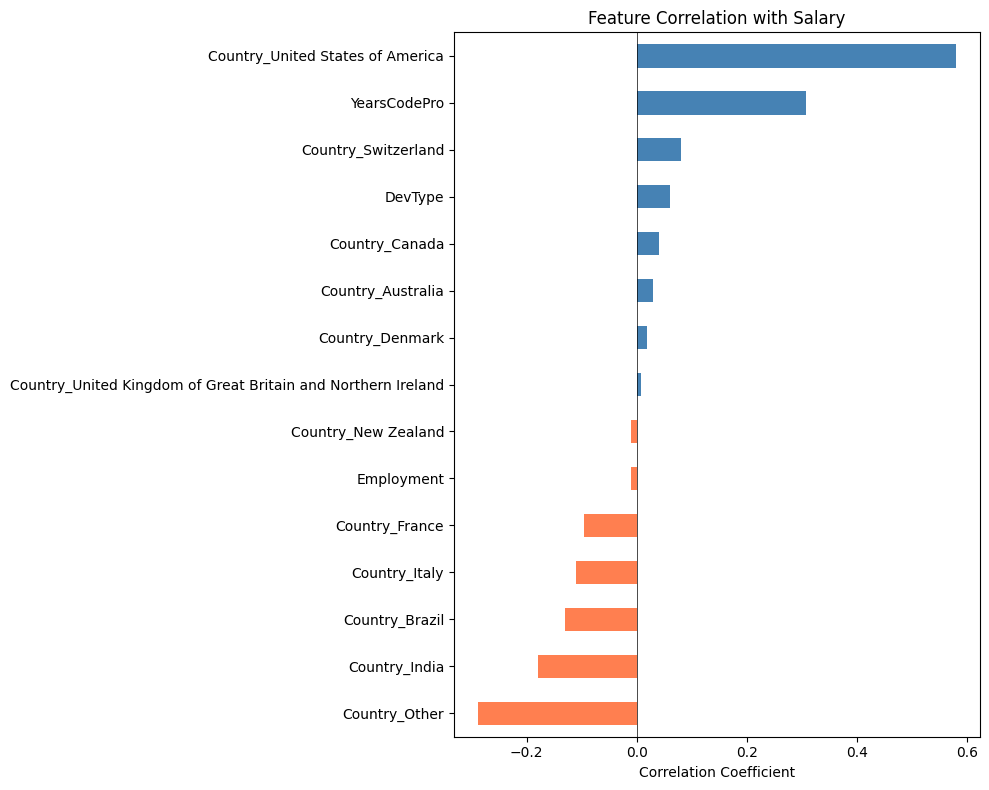


Most positively correlated with salary:
Country_Switzerland                 0.080300
YearsCodePro                        0.308599
Country_United States of America    0.580711
Name: ConvertedCompYearly, dtype: float64

Most negatively correlated with salary:
Country_Other    -0.288902
Country_India    -0.178747
Country_Brazil   -0.130467
Name: ConvertedCompYearly, dtype: float64


In [56]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate correlation of every feature with salary
correlations = df.corr()['ConvertedCompYearly'].drop('ConvertedCompYearly').sort_values()

# Only show top 10 and bottom 5 to keep the chart readable
correlations_to_show = pd.concat([correlations.head(5), correlations.tail(10)])

plt.figure(figsize=(10, 8))
correlations_to_show.plot(kind='barh', color=['coral' if x < 0 else 'steelblue' for x in correlations_to_show])
plt.title('Feature Correlation with Salary')
plt.xlabel('Correlation Coefficient')
plt.axvline(x=0, color='black', linewidth=0.5)
plt.tight_layout()
plt.show()

print("\nMost positively correlated with salary:")
print(correlations.tail(3))
print("\nMost negatively correlated with salary:")
print(correlations.head(3))